# PSS: how do ABA, JA and SA reach RD29?

This tutorial works through a question from the
[SKM publication](https://doi.org/10.1016/j.xplc.2024.100920) (case study 1) with the
Plant Stress Signalling model (PSS):

> ABA induces the expression of *RD29* in Arabidopsis and potato. Adding SA or JA
> weakens this induction, although on their own they have no effect. Where could the
> SA and JA pathways meet the ABA → RD29 pathway?

Along the way, it shows how to:

- load the PSS networks and look at their nodes and edges,
- filter PSS by node type and species,
- find shortest paths, neighbourhoods and minimum cuts,
- find nodes by MapMan bin,
- go from functional clusters to genes with a gene network,
- save the results, and export them for DiNAR,
- show the results in Cytoscape.

The Cytoscape cells (the last section) need a running Cytoscape; everything else runs
without it. See the [skm-tools documentation](https://nib-si.github.io/skm-tools) for
more on each function.

In [1]:
from collections import Counter
from pathlib import Path

import networkx as nx
import pandas as pd

from skm_tools.annotations import get_nodes_by_mapman
from skm_tools.cuts import get_cutset
from skm_tools.dinar import write_dinar
from skm_tools.neighbors import get_neighborhood
from skm_tools.paths import get_paths, path_edges, path_subgraph
from skm_tools.persistence import save_graph
from skm_tools.pss import (
    filter_pss_nodes,
    pss_gene_network_to_networkx,
    pss_interaction_network_to_networkx,
    simplify_pss,
)

data_dir = Path("data")
output_dir = Path("output")
data_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)

## Loading PSS

PSS comes as three networks: the reaction graph (reactions as nodes), the interaction
network (entity → entity influences) and a gene network per species (the interaction
network with functional clusters replaced by their genes). Here we use the interaction
network. The files are downloaded from [skm.nib.si](https://skm.nib.si) the first time,
into `data/`.

In [2]:
pss = pss_interaction_network_to_networkx(
    data_dir / "pss-interaction-network-edges-public.tsv",
    data_dir / "pss-interaction-network-nodes-public.tsv",
)
print(pss)

MultiDiGraph with 749 nodes and 1567 edges


Plant genes are grouped in *functional clusters*, named `short_name[functional_cluster_id]`;
`display_label` has the name to show. A small helper finds nodes by their label:

In [3]:
def find(g, label):
    """The nodes of g with this display_label."""
    return [n for n, d in g.nodes(data=True) if d["display_label"] == label]


RD29 = find(pss, "RD29")[0]
RD29

'RD29[fc00192]'

In [4]:
{k: v for k, v in pss.nodes[RD29].items() if k in ("node_type", "display_label", "description", "pathway", "ath_homologues")}

{'node_type': 'PlantCoding',
 'display_label': 'RD29',
 'description': 'Responsive to Desiccation 29',
 'pathway': 'Stress - Drought',
 'ath_homologues': ['AT5G52300', 'AT5G52310']}

Edges are entity → entity influences through a reaction, keyed by the reaction id. A
node pair can be linked by several reactions:

In [5]:
pd.DataFrame([
    {"source": u, "target": v, "reaction_id": k, **{a: d[a] for a in ("interaction", "reaction_type", "directed")}}
    for u, v, k, d in pss.in_edges(RD29, keys=True, data=True)
])

,source,target,reaction_id,interaction,reaction_type,directed
0,AREB/ABF[fc00397],RD29[fc00192],rx00605,positive-influence,transcriptional/translational activation,True


## Filtering

PSS also covers pathogens (e.g. viral proteins), and functional clusters without genes in
the species we study. We keep the plant node types, and the reactions whose functional
clusters have genes in Arabidopsis or potato. `filter_pss_nodes` changes the network in
place, and returns why each node was removed.

In [6]:
Counter(d["node_type"] for _, d in pss.nodes(data=True))

Counter({'PlantCoding': 438,
         'Metabolite': 136,
         'Complex': 116,
         'ForeignCoding': 12,
         'Process': 10,
         'MetaboliteFamily': 9,
         'PlantAbstract': 8,
         'PlantNonCoding': 8,
         'ForeignNonCoding': 5,
         'ForeignAbiotic': 4,
         'ForeignEntity': 3})

In [7]:
keep_types = ["Complex", "ForeignAbiotic", "Metabolite", "MetaboliteFamily", "PlantAbstract",
              "PlantCoding", "PlantNonCoding", "Process"]

removed = filter_pss_nodes(pss, node_types=keep_types, species=["ath", "stu"])
Counter(removed.values())

Removed 87 nodes from network.


Counter({'isolate': 54,
         'wrong node type': 20,
         'species missing': 7,
         'complex component removed': 6})

## Shortest paths

The shortest paths from ABA, JA and SA to RD29:

In [8]:
label = dict(pss.nodes(data="display_label"))

paths = {source: get_paths(pss, source, RD29) for source in ["ABA", "JA", "SA"]}
for source, source_paths in paths.items():
    for p in source_paths:
        print(" → ".join(label[n] for n in p))

ABA → PYL → MYC2 → DELLA → AREB/ABF → RD29
ABA → PYL → PP2C → SNRK2 → AREB/ABF → RD29
JA → JA-Ile → COI1|JA-Ile|SCF → JAZ → DELLA → AREB/ABF → RD29
SA → NPR1 → MYC2 → DELLA → AREB/ABF → RD29


JA and SA reach the ABA pathway at MYC2 and DELLA, before AREB/ABF activates RD29:

In [9]:
on_aba_paths = {n for p in paths["ABA"] for n in p}
for source in ["JA", "SA"]:
    shared = [label[n] for p in paths[source] for n in p if n in on_aba_paths]
    print(source, "meets the ABA paths at:", ", ".join(dict.fromkeys(shared)))

JA meets the ABA paths at: DELLA, AREB/ABF, RD29
SA meets the ABA paths at: MYC2, DELLA, AREB/ABF, RD29


Every step of a path is a reaction. The edges along the ABA paths, with their reactions:

In [10]:
pd.DataFrame([
    {"source": label[u], "interaction": d["interaction"], "target": label[v],
     "reaction_id": k, "reaction_type": d["reaction_type"]}
    for u, v, k in path_edges(paths["ABA"], pss)
    for d in [pss.edges[u, v, k]]
])

,source,interaction,target,reaction_id,reaction_type
0,ABA,positive-influence,PYL,rx00474,protein activation
1,PYL,negative-influence,MYC2,rx00459,binding/oligomerisation
2,MYC2,negative-influence,DELLA,rx00162,binding/oligomerisation
3,MYC2,positive-influence,DELLA,rx00163,transcriptional/translational activation
4,DELLA,negative-influence,AREB/ABF,rx00608,degradation/secretion
5,AREB/ABF,positive-influence,RD29,rx00605,transcriptional/translational activation
6,PYL,negative-influence,PP2C,rx00475,protein deactivation
7,PP2C,negative-influence,SNRK2,rx00476,protein deactivation
8,SNRK2,positive-influence,AREB/ABF,rx00569,protein activation
9,SNRK2,negative-influence,AREB/ABF,rx00610,transcriptional/translational repression


## Neighbourhoods

What else is DELLA connected to? `get_neighborhood` returns the subnetwork around nodes
(here the first neighbours, in both directions), with each node's `distance`:

In [11]:
DELLA = find(pss, "DELLA")[0]
della = get_neighborhood(pss, DELLA, depth=1)
sorted(label[n] for n in della if n != DELLA)

['ABI4',
 'ABI4|RGL2',
 'AREB/ABF',
 'CO',
 'GAI|GI',
 'GA|GID1',
 'GI',
 'JAZ',
 'MYC2',
 'PIF3,4']

## Minimum cuts

Which interactions carry JA and SA into the ABA pathway, at DELLA? `get_cutset` finds the
smallest set of edges whose removal cuts the sources off from the targets. It needs a
simple directed graph with a `capacity` on each edge: `simplify_pss` merges the parallel
edges (one per reaction) into one edge per node pair, keeping all their reaction ids. For
the other attributes it keeps one value, and reports how many merged edges had differing
values (`verbose=True` lists them). Each edge counts as 1.

In [12]:
simple = simplify_pss(pss)
nx.set_edge_attributes(simple, 1, "capacity")

cut = get_cutset(["JA", "SA"], [DELLA], simple)
[(label[u], label[v]) for u, v in cut]

Merged edges with differing values (one value kept): evidence_sentence (18), experimental_techniques (18), influence_sbo (17), interaction (17), target_role (16), source_location_putative (8), reaction_sbo (8), reaction_type (8), source_role (7), reaction_mechanism (7), target_location_putative (6), directed (6), reaction_effect (6), reaction_mechanism_sbo (5), target_form (4), source_form (3), target_location (3), source_location (2). See verbose=True for details.


max_flow = 3


[('GA|GID1', 'DELLA'), ('JAZ', 'DELLA'), ('MYC2', 'DELLA')]

## MapMan bins

Nodes are annotated with the MapMan bins (MapMan4) of their Arabidopsis genes, as
`<bin code>_<bin name>`. `get_nodes_by_mapman` finds the nodes in a bin, including its
sub-bins. Bin 10.1 is *Phytohormone action. abscisic acid*:

In [13]:
def bins(node, code=""):
    """The node's MapMan bins (starting with code), shortened for display."""
    return [b.split(" *(")[0] for b in pss.nodes[node]["mapman"] or [] if b.startswith(code)]


for n in get_nodes_by_mapman(pss, "10.1"):
    print(f"{label[n]:10}", bins(n, "10.1"))

AAO        ['10.1.1.7_Phytohormone action.abscisic acid.biosynthesis.abscisic aldehyde oxidase']
ABA2       ['10.1.1.5_Phytohormone action.abscisic acid.biosynthesis.xanthoxin oxidase']
CYP707A3   ['10.1.3.1_Phytohormone action.abscisic acid.conjugation and degradation.abscisic acid hydroxylase']
NCED       ['10.1.1.4_Phytohormone action.abscisic acid.biosynthesis.9-cis-epoxycarotenoid dioxygenase']
PYL        ['10.1.2.1.1.1_Phytohormone action.abscisic acid.perception and signalling.receptor activities.cytoplasm-localized receptor complex.receptor component']
ZEP        ['10.1.1.1_Phytohormone action.abscisic acid.biosynthesis.zeaxanthin epoxidase']


Bin 10.1 has the ABA biosynthesis genes (ZEP, NCED, ABA2, AAO), its breakdown
(CYP707A3) and its receptor (PYL), but of the ABA signalling route to RD29 only PYL. MapMan
classifies genes by their molecular function: the phosphatase PP2C is in the protein
dephosphorylation bins (18.5), the kinase SnRK2 in the phosphorylation bins (18.4), and
AREB/ABF in the transcription factor bins (14.5):

In [14]:
for n in dict.fromkeys(n for p in paths["ABA"] for n in p):
    print(f"{label[n]:10}", bins(n))

ABA        []
PYL        ['10.1.2.1.1.1_Phytohormone action.abscisic acid.perception and signalling.receptor activities.cytoplasm-localized receptor complex.receptor component']
MYC2       ['10.7.2.1.2_Phytohormone action.jasmonic acid.perception and signal transduction.receptor activities.regulatory protein', '14.5.1.2.8_RNA biosynthesis.DNA-binding transcriptional regulation.basic DNA-binding domain.basic helix-loop-helix (bHLH) domain.bHLH class-IIIe transcription factor']
DELLA      ['10.6.2.2_Phytohormone action.gibberellin.perception and signal transduction.DELLA-type transcriptional repressor', '14.5.10.2_RNA biosynthesis.DNA-binding transcriptional regulation.undefined DNA-binding domain.GRAS transcription factor', '26.7.2.1_External stimuli response.salinity.gibberellin-abscisic acid signalling pathways crosstalk.DELLA-type transcription factor']
AREB/ABF   ['14.5.1.1.1.1_RNA biosynthesis.DNA-binding transcriptional regulation.basic DNA-binding domain.basic leucine zipper (bZI

So MapMan bins are good for finding genes of a molecular function (e.g. all receptors, or
all bZIP transcription factors). To find the nodes of a signalling pathway, use the PSS
pathways instead: `all_pathways` has all the pathways of a node (`pathway` only its main
one). Of the ABA route to RD29, these are in the ABA pathway:

In [15]:
aba_pathway = [n for n, d in pss.nodes(data=True)
               if "Hormone - Abscisic acid (ABA)" in (d["all_pathways"] or [])]
print(len(aba_pathway), "nodes in the ABA pathway")
sorted(label[n] for n in aba_pathway if n in on_aba_paths)

35 nodes in the ABA pathway


['AREB/ABF', 'PYL', 'RD29', 'SNRK2']

## From functional clusters to genes

The gene network of a species has the genes of each functional cluster as nodes, so
paths can be followed gene by gene. In the Arabidopsis gene network, the RD29 cluster
(`fc00192`) has these genes:

In [16]:
genes_ath = pss_gene_network_to_networkx(
    data_dir / "pss-gene-network-ath-edges-public.tsv",
    data_dir / "pss-gene-network-ath-nodes-public.tsv",
    species="ath",
)
rd29_genes = [n for n, d in genes_ath.nodes(data=True)
              if "fc00192" in (d.get("functional_cluster_id") or [])]
rd29_genes

['AT5G52300', 'AT5G52310']

In [17]:
gene_paths = get_paths(genes_ath, "ABA", rd29_genes)
print(len(gene_paths), "gene-level shortest paths, e.g.:")
gene_label = dict(genes_ath.nodes(data="display_label"))
for p in gene_paths[:3]:
    print(" → ".join(f"{gene_label[n]} ({n})" if n != gene_label[n] else n for n in p))

128 gene-level shortest paths, e.g.:
ABA → PYL (AT1G01360) → MYC2 (AT1G32640) → DELLA (AT5G17490) → AREB/ABF (AT1G49720) → RD29 (AT5G52300)
ABA → PYL (AT2G40330) → MYC2 (AT1G32640) → DELLA (AT5G17490) → AREB/ABF (AT1G49720) → RD29 (AT5G52300)
ABA → PYL (AT1G01360) → MYC2 (AT1G32640) → DELLA (AT3G03450) → AREB/ABF (AT1G49720) → RD29 (AT5G52300)


## Saving

The path subnetwork can be saved for later (pickle, JSON or GraphML), and the gene
network exported as a [DiNAR](https://github.com/NIB-SI/DiNAR) custom network, to show
expression data on it (one cluster per pathway):

In [18]:
all_paths = [p for source_paths in paths.values() for p in source_paths]
paths_net = path_subgraph(all_paths, pss)
save_graph(paths_net, output_dir / "pss-paths-to-RD29.json", format="json")

write_dinar(genes_ath, output_dir / "pss-ath-dinar-nodes.txt", output_dir / "pss-ath-dinar-edges.txt",
            clusters="pathway")
print(paths_net)

MultiDiGraph with 14 nodes and 18 edges


## Cytoscape

The rest of this tutorial needs a running Cytoscape, and the `cytoscape` extra
(`pip install "skm-tools[cytoscape]"`). We load the filtered PSS with the SKM style,
highlight the paths from ABA, JA and SA in different colours, and make a subnetwork with
only the paths.

In [19]:
# ci-skip: needs a running Cytoscape
import py4cytoscape as p4c
from IPython.display import Image

from skm_tools import cytoscape_utils as cu

p4c.cytoscape_ping()

'You are connected to Cytoscape!'

In [20]:
# ci-skip: needs a running Cytoscape
suid = cu.load_network(pss, title="PSS (filtered)", collection="Tutorial: PSS", style="skm")

Applied SKM to 26449


Highlight each source's paths in its own colour. Nodes and edges already highlighted are
skipped, so the paths from JA and SA don't paint over the ABA paths where they meet:

In [21]:
# ci-skip: needs a running Cytoscape
colours = {"ABA": "#E41A1C", "JA": "#377EB8", "SA": "#4DAF4A"}
done_nodes, done_edges = [], []
for source, source_paths in paths.items():
    for p in source_paths:
        nodes, edges = cu.highlight_path(p, colours[source], skip_nodes=done_nodes,
                                         skip_edges=done_edges, network=suid)
        done_nodes += nodes
        done_edges += edges

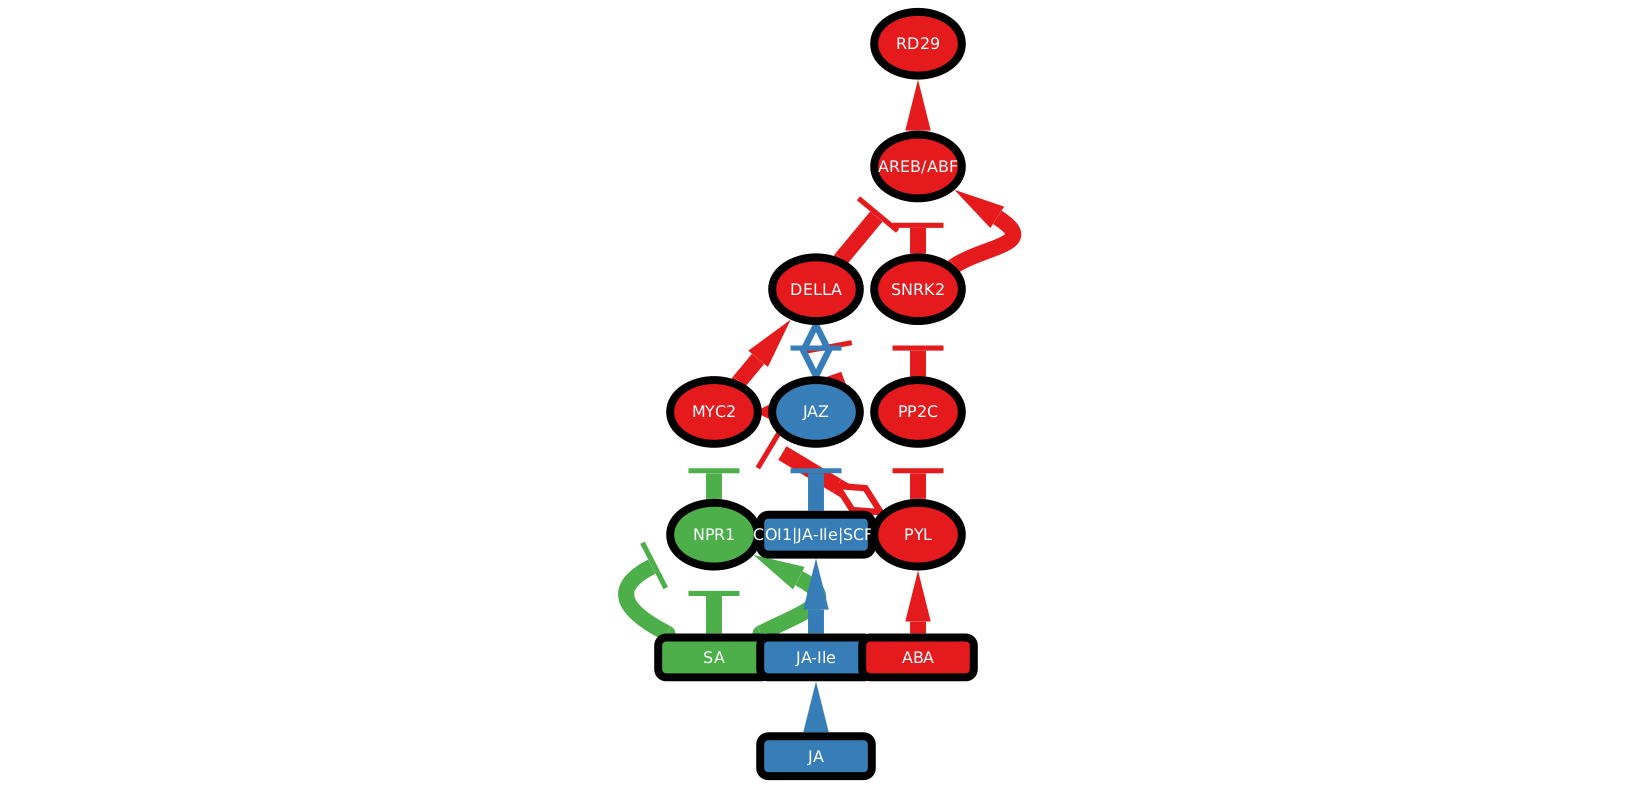

In [22]:
# ci-skip: needs a running Cytoscape
paths_suid = cu.subnetwork_edge_induced_from_paths(all_paths, pss, suid, name="Paths to RD29")
p4c.layout_network("hierarchical", network=paths_suid)
cu.export_network(paths_suid, output_dir / "pss-paths-to-RD29.png", format="PNG", zoom=200)
Image(output_dir / "pss-paths-to-RD29.png")